# Model comparison — pdfplumber

Three models on the same 10 Data Management Plans, the same extraction, and the
same prompt. Text-block classification into five classes.

Because stage 1 is cached per extractor, every model here received **identical
blocks** — so any difference below is the model.

> **Scored at 75% overlap.** A predicted item counts as matching a
> reference item only when **every one of its words** appears in that reference
> item — no partial credit. The project default is 75%, so these figures are
> stricter than the ones in the other notebooks and are not comparable with them.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.annotation_rules import load_method_new
from dmpbridge.evaluation.annotation_rules import resolve_new_gt_path
from dmpbridge.evaluation.evaluate import (
    CONTAINMENT_THRESHOLD, LABELS, _confusion_from_match, _match_structured,
    add_confusion, compute_f1_rows, containment, extract_gold, load_method,
    micro_prf1, resolve_old_gt_path, tokenize,
)

MODELS, EXTRACTOR, SAMPLES = ['llama3.1:8b', 'gemma4:e4b', 'llama3.3:70b', 'qwen2.5:14b'], 'pdfplumber', range(1, 11)
THRESHOLD = 0.75   # None = the project default (0.75)

# Reference categorical palette, slots 1-3-5 — one hue per model, held
# constant in every chart below. Slot 4 (yellow) is skipped: the palette's
# own reference doc measures it failing the all-pairs floor against slot 2
# (orange) once both are on screen together, so slot 5 (magenta) is used
# for the 4th model instead.
COLOURS = ['#2a78d6', '#eb6834', '#1baf7a', '#e87ba4']
INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})
pd.set_option('display.max_colwidth', 60)

available, CONF = [], {}
for m in MODELS:
    tag = P.make_tag(m, EXTRACTOR)
    if not all(P.structured_path(tag, n).exists() for n in SAMPLES):
        print('not yet run, skipped:', m)
        continue
    available.append(m)
    CONF[m] = {'A': load_method(tag, exclude=[], threshold=THRESHOLD)[1],
               'B': load_method_new(tag, exclude=[], threshold=THRESHOLD)[1]}

COLOUR = dict(zip(available, COLOURS))
print('comparing:', ', '.join(available))


comparing: llama3.1:8b, gemma4:e4b, llama3.3:70b, qwen2.5:14b


## 1. Metrics

Each predicted block is matched to a reference block by token overlap, giving three
possible outcomes:

| | |
|---|---|
| **TP** &nbsp;true positive | matched to a reference block, with the same class |
| **FP** &nbsp;false positive | predicted with the wrong class, or with no reference counterpart |
| **FN** &nbsp;false negative | a reference block not matched, or matched with the wrong class |

```
precision  =  TP / (TP + FP)
recall     =  TP / (TP + FN)
f1-score   =  2 * precision * recall / (precision + recall)
```

Precision falls when the model over-generates; recall falls when it under-generates.
The f1-score is their harmonic mean, so it stays low unless both are high.

### The two paths

| | prediction scored | reference |
|---|---|---|
| **Path A** | stage 3, the model's structured output as produced | the original annotation |
| **Path B** | stage 4, the same output after the annotation rules are applied | the revised annotation |

Compare models **down a column**, never Path A against Path B — the two paths score
different numbers of items.


In [2]:
rows = []
for m in available:
    a, b = micro_prf1(CONF[m]['A']), micro_prf1(CONF[m]['B'])
    rows.append({'model': m,
                 'precision': a['precision'], 'recall': a['recall'],
                 'Path A f1': a['f1'], 'Path B f1': b['f1'],
                 'TP': a['tp'], 'FP': a['fp'], 'FN': a['fn']})

head = pd.DataFrame(rows).set_index('model')
display(head.style
        .background_gradient(cmap='Greens', subset=['Path A f1', 'Path B f1'])
        .format({'precision': '{:.3f}', 'recall': '{:.3f}',
                 'Path A f1': '{:.3f}', 'Path B f1': '{:.3f}'}))


,precision,recall,Path A f1,Path B f1,TP,FP,FN
model,,,,,,,
llama3.1:8b,0.546,0.629,0.585,0.556,83,69,49
gemma4:e4b,0.865,0.826,0.845,0.792,109,17,23
llama3.3:70b,0.570,0.652,0.608,0.586,86,65,46
qwen2.5:14b,0.673,0.811,0.735,0.720,107,52,25


## 2. Classification report

Per class, every model side by side. Support is the number of reference blocks of
that class and is the same for all models, so the scores are directly comparable.

**These figures cover all 10 documents at once.** The counts are pooled first and the
score computed from the total — not worked out per document and then averaged. A long
document therefore carries more weight than a short one, which is what you want when
the question is how the model performs on this corpus.


In [3]:
for path, name in (('A', 'Path A — model output as produced'),
                   ('B', 'Path B — after the annotation rules')):
    per = {m: compute_f1_rows(CONF[m][path]).set_index('label') for m in available}
    tbl = pd.DataFrame({m: per[m]['f1'] for m in available})
    tbl.insert(0, 'support', per[available[0]]['support'].astype(int))
    tbl.loc['micro avg'] = [tbl['support'].sum()] + \
                           [micro_prf1(CONF[m][path])['f1'] for m in available]
    tbl.index.name = 'f1-score'
    display(tbl.style
            .set_caption(name)
            .set_table_styles([{'selector': 'caption',
                                'props': [('caption-side', 'top'),
                                          ('font-size', '110%'),
                                          ('font-weight', '600'),
                                          ('text-align', 'left'),
                                          ('padding-bottom', '6px'),
                                          ('color', INK)]}])
            .background_gradient(cmap='Greens', subset=available, axis=None)
            .format({m: '{:.3f}' for m in available} | {'support': '{:.0f}'}))
    print()


,support,llama3.1:8b,gemma4:e4b,llama3.3:70b,qwen2.5:14b
f1-score,,,,,
title,10,0.800,0.800,0.737,0.842
section.title,43,0.593,0.786,0.742,0.760
section.description,8,0.200,0.941,0.211,0.667
question.text,16,0.000,0.812,0.649,0.545
answer.text,55,0.719,0.895,0.600,0.765
micro avg,132,0.585,0.845,0.608,0.735


,support,llama3.1:8b,gemma4:e4b,llama3.3:70b,qwen2.5:14b
f1-score,,,,,
title,10,0.800,0.800,0.737,0.842
section.title,43,0.587,0.759,0.733,0.752
section.description,8,0.200,0.824,0.211,0.667
question.text,56,0.383,0.710,0.554,0.655
answer.text,55,0.719,0.895,0.600,0.748
micro avg,172,0.556,0.792,0.586,0.720


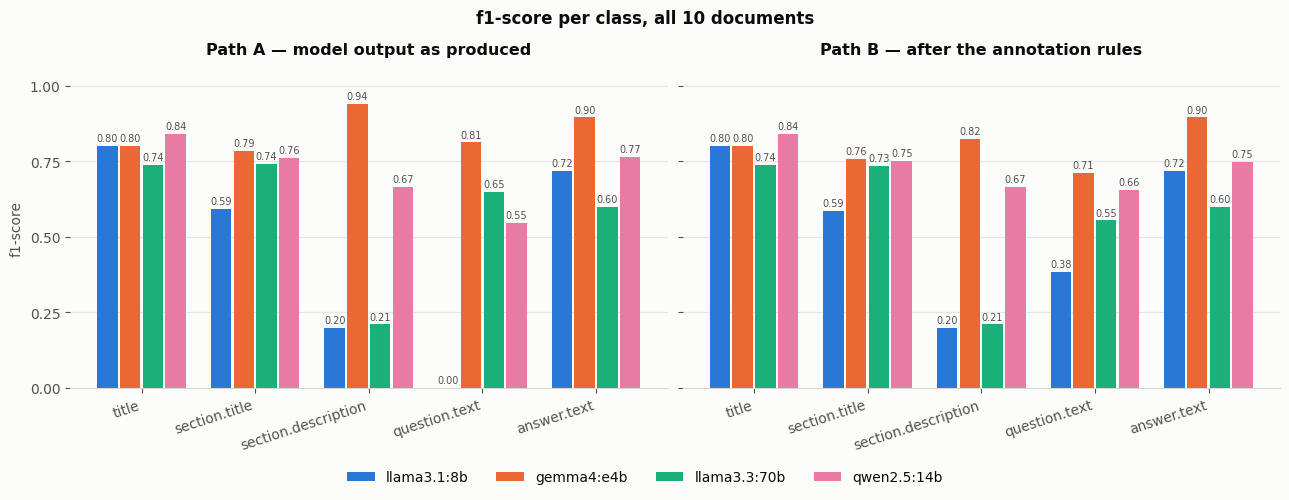

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), sharey=True)
w = 0.8 / max(len(available), 1)

for ax, path, name in zip(axes, ('A', 'B'), ('Path A', 'Path B')):
    per = {m: compute_f1_rows(CONF[m][path]).set_index('label') for m in available}
    x = np.arange(len(LABELS))
    for k, m in enumerate(available):
        vals = [per[m]['f1'].get(l, 0) for l in LABELS]
        bars = ax.bar(x + (k - (len(available) - 1) / 2) * w, vals,
                      width=w - 0.02, color=COLOUR[m], label=m)
        ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7, color=MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, rotation=18, ha='right')
    ax.set_ylim(0, 1.06)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_title('Path A — model output as produced' if path == 'A'
                 else 'Path B — after the annotation rules', pad=10)
    ax.grid(axis='y', color=GRID, linewidth=0.9)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)

axes[0].set_ylabel('f1-score')
plt.tight_layout()

# Legend below the panels: at the top it collides with the two subplot
# titles, which are long enough to reach the middle of the figure.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(available), loc='upper center',
           bbox_to_anchor=(0.5, 0.02))
fig.suptitle('f1-score per class, all 10 documents',
             fontweight='bold', y=1.04)
plt.show()


The label to watch is `question.text`. It is where the models separate most, and it
is the one the annotation rules target — compare its Path A and Path B bars for each
model to see how much the rules recover.


### The same thing averaged the other way

Everything above **adds the counts from all 10 documents together, then computes one
score**. A document with 55 blocks therefore counts far more than one with 2.

The alternative is to **score each document on its own, then average the ten scores**,
so every document counts equally regardless of length.

```
pooled       :  add up TP, FP, FN across all 10  ->  one f1
per-document :  f1 for each document  ->  mean of the 10
```

Neither is more correct; they answer different questions. Pooled asks *how does the
model do on this corpus*. Per-document asks *how does it do on a typical document*.

The `documents` column says how many of the ten went into each row. A document counts
for a class when the class **is in the annotation there, or the model predicted it
there anyway** — the second case scores 0, because everything produced is a false
positive. Only documents where the class is both absent and unpredicted are left out,
since there is genuinely nothing to score.


In [5]:
def per_document_f1(model, path):
    """f1 for each class in each document, scored independently.

    A document counts for a class when the class is present in the annotation
    **or** the model predicted it there. The second case matters: if a class
    does not occur in a document and the model produces it anyway, every one
    of those is a false positive, and f1 for that document is 0. Skipping
    those documents would report a perfect mean while hiding the errors.

    A document where the class is neither present nor predicted is genuinely
    not applicable and is left out.
    """
    tag = P.make_tag(model, EXTRACTOR)
    rows = []
    for n in SAMPLES:
        if path == 'A':
            gold = extract_gold(resolve_old_gt_path(n))
            rec, ng = _match_structured(P.structured_path(tag, n), gold)
        else:
            gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
            rec, ng = _match_structured(P.final_path(tag, n), gold,
                                        dedup_question_title=False)
        conf = _confusion_from_match(rec, ng)
        f1s = compute_f1_rows(conf).set_index('label')
        for lab in LABELS:
            support = f1s.loc[lab, 'support'] if lab in f1s.index else 0
            predicted = (sum(conf.get(t, {}).get(lab, 0) for t in LABELS)
                         + conf.get('__no_gold__', {}).get(lab, 0))
            if support > 0:
                rows.append({'sample': n, 'label': lab,
                             'f1': f1s.loc[lab, 'f1']})
            elif predicted:
                rows.append({'sample': n, 'label': lab, 'f1': 0.0})
    return pd.DataFrame(rows)


for path, name in (('A', 'Path A'), ('B', 'Path B')):
    cols = {}
    for m in available:
        d = per_document_f1(m, path)
        g = d.groupby('label')['f1']
        cols[(m, 'mean')] = g.mean()
        # Population sd over the documents that contain the class. With
        # only a handful of documents this is descriptive, not inferential.
        cols[(m, 'sd')] = g.std(ddof=0)
        if m == available[0]:
            n_docs = g.count()
    tbl = pd.DataFrame(cols).reindex(LABELS)
    tbl.insert(0, ('', 'documents'), n_docs)
    tbl.columns = pd.MultiIndex.from_tuples(tbl.columns)
    tbl.index.name = 'f1 per document'
    display(tbl.style
            .set_caption(f'{name} — each document scored separately, then averaged')
            .set_table_styles([{'selector': 'caption',
                                'props': [('caption-side', 'top'),
                                          ('font-size', '110%'),
                                          ('font-weight', '600'),
                                          ('text-align', 'left'),
                                          ('padding-bottom', '6px'),
                                          ('color', INK)]}])
            .background_gradient(cmap='Greens',
                                 subset=[(m, 'mean') for m in available], axis=None)
            .background_gradient(cmap='Purples',
                                 subset=[(m, 'sd') for m in available], axis=None)
            .format('{:.3f}')
            .format('{:.0f}', subset=[('', 'documents')]))
    print()


**Where the two tables disagree, the reason is document size.** A class the model
handles well in several small documents and badly in one large one scores higher here
than in the pooled table, because the large document no longer dominates.

**The `sd` column is how much the score moves from document to document.** A mean of
0.70 with an sd of 0.05 is a model that behaves the same way everywhere. The same mean
with an sd of 0.35 is one that is excellent on some documents and useless on others —
and the average describes neither case.

Two cautions on reading it:

- **It is not the same as run-to-run noise.** Repeating an identical run moves the
  score by about ±0.002. The spread here is between *documents*, and is far larger.
- **Check the `documents` column first.** An sd computed from 2 documents is barely
  meaningful; from 10 it is worth taking seriously.

Quote whichever average you like, but say which — and do not mix them in one
comparison.


## 3. Confusion matrices — % of each true class

Rows are the true class, columns the predicted class; the outlined diagonal is
agreement.

**Each cell is a percentage of its row's class**: "this share of the real
`question.text` items was predicted as `section.title`". Raw counts mislead here
because the classes are imbalanced — 55 answers against 8 descriptions — so a count
of 4 is trivial in one row and half the class in another. As percentages every row
reads on the same scale, and **the diagonal cell is that class's recall**.

**The last column, `(not labeled)`, is annotation items the model produced nothing
for at all** — no predicted item matched them. It is separated by a rule because it
is not a label the model chose; it is the absence of one. With it included every row
sums to 100%.

One thing the matrix cannot show: predicted items that match *no* annotation item
(false positives). They have no true class, so they belong to no row. Section 2's
precision and f1 figures account for them.

**Top row is Path A, bottom row is Path B**, so reading down a column shows what the
annotation rules changed for that model. All panels share one colour scale, 0–100%.


saved -> Report-doc\confusion_pathA_pdfplumber_75pct.png


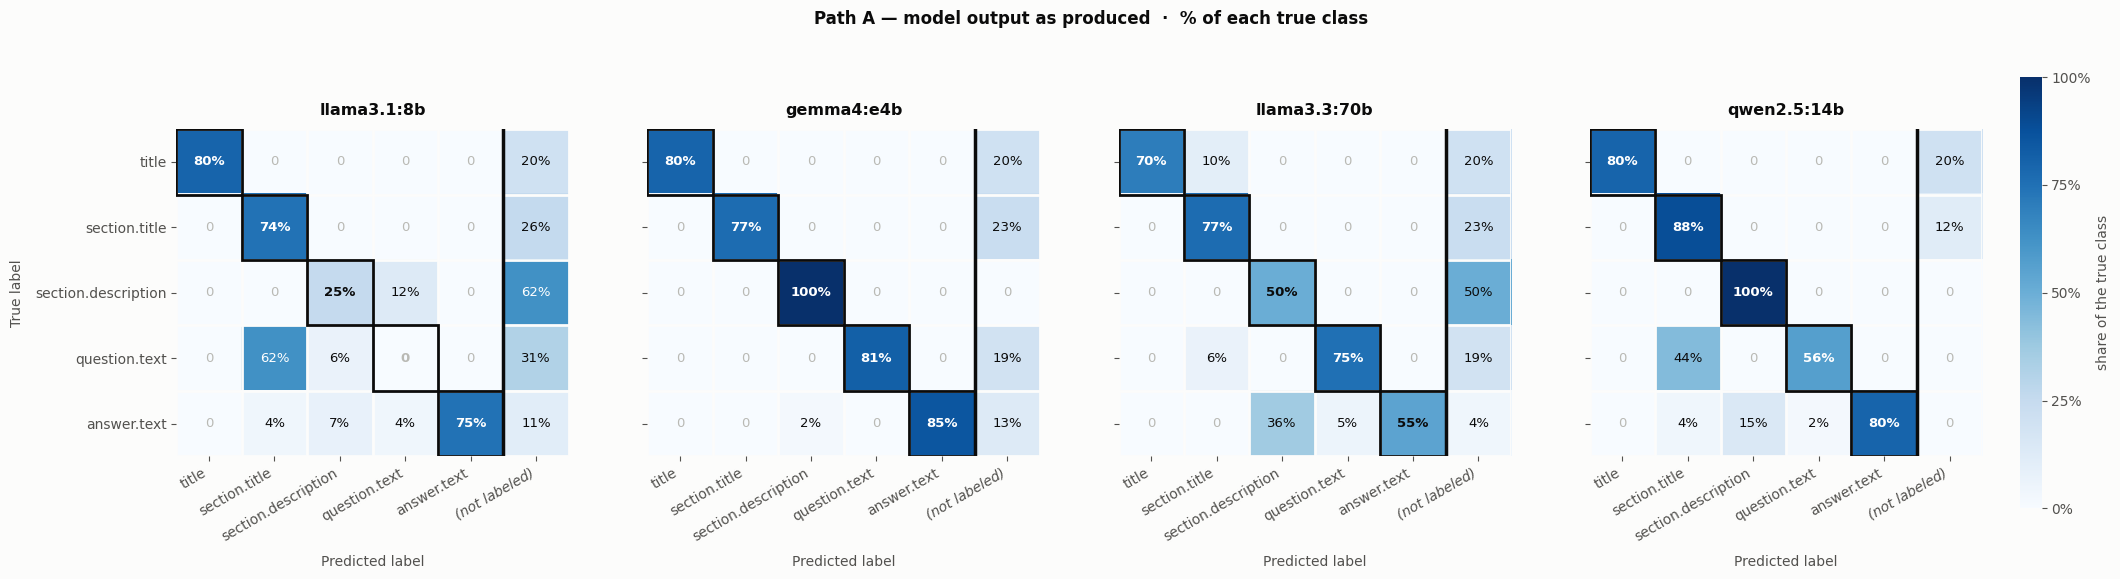

saved -> Report-doc\confusion_pathB_pdfplumber_75pct.png


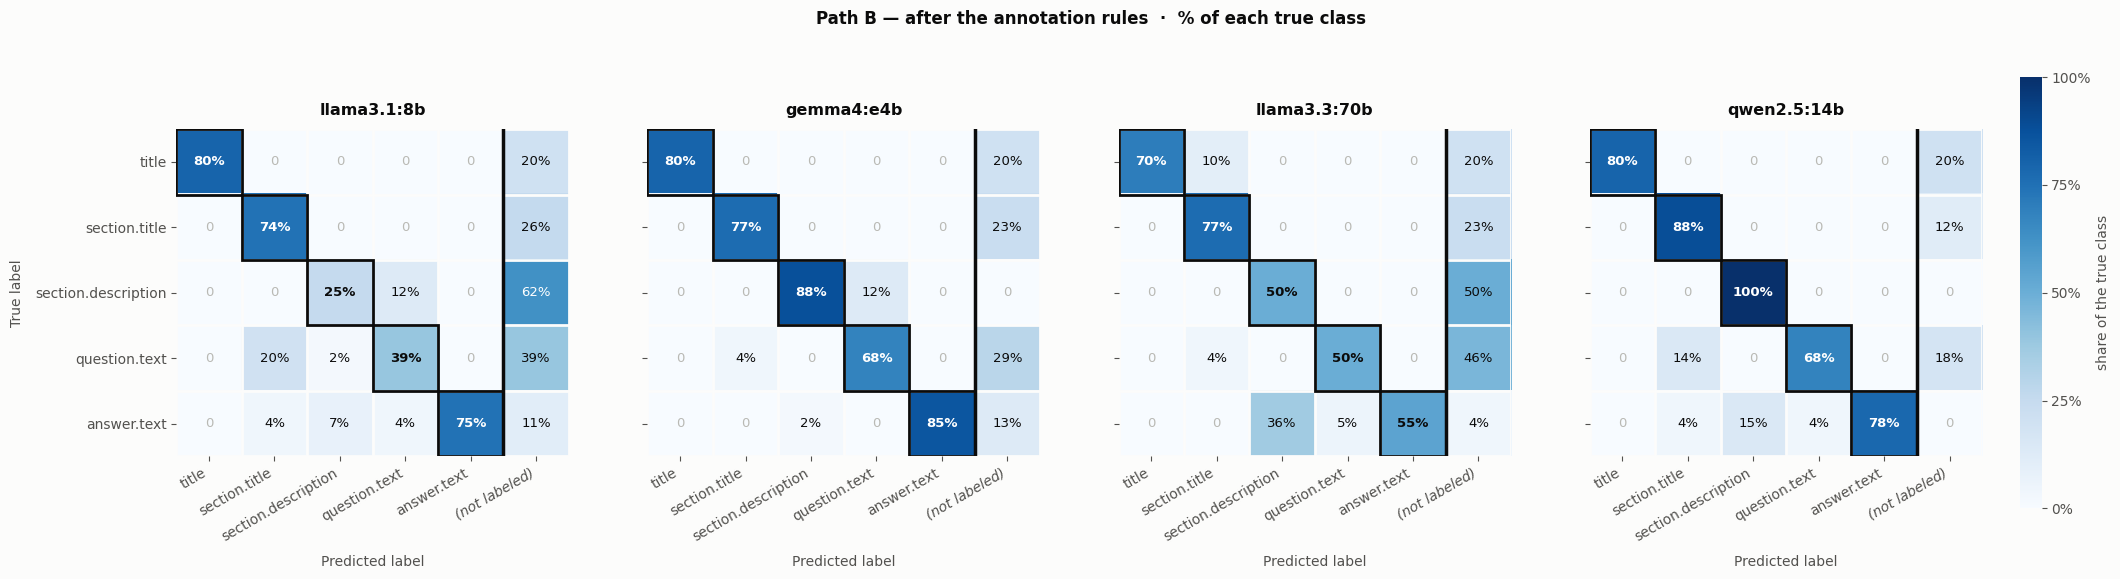

In [6]:
# The five labels, plus one extra column for annotation items the model
# produced nothing for. Without that column the rows do not add up to 100%.
COLS = list(LABELS) + ['(not labeled)']
KEYS = list(LABELS) + ['__missed__']


def build_pct(conf):
    """Row-percentage matrix: cell (i, j) = share of true class i predicted
    as j, out of ALL real items of class i. The final column holds the ones
    never produced, so the diagonal is exactly recall and each row sums to 1."""
    pct = np.zeros((len(LABELS), len(KEYS)))
    for i, t in enumerate(LABELS):
        row_total = sum(conf.get(t, {}).values())
        for j, key in enumerate(KEYS):
            if row_total:
                pct[i, j] = conf.get(t, {}).get(key, 0) / row_total
    return pct


PATH_NAMES = {'A': 'Path A — model output as produced',
              'B': 'Path B — after the annotation rules'}


def draw_path(path):
    """One figure per path: the models side by side, saved as a PNG for slides."""
    ncol = max(len(available), 1)
    fig, axes = plt.subplots(1, ncol, figsize=(6.1 * ncol, 5.6),
                             squeeze=False)
    for c, m in enumerate(available):
        ax, cm = axes[0][c], build_pct(CONF[m][path])
        im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
        for i in range(len(LABELS)):
            for j in range(len(KEYS)):
                v = cm[i, j]
                ax.text(j, i, f'{v:.0%}' if v else '0', ha='center',
                        va='center', fontsize=9.5,
                        fontweight='bold' if i == j else 'normal',
                        color='#b9b9b4' if v == 0
                        else ('white' if v > 0.55 else INK))
        ax.set_xticks(range(len(COLS)))
        ax.set_yticks(range(len(LABELS)))
        ax.set_xticklabels(COLS, rotation=30, ha='right')
        ax.set_yticklabels(LABELS if c == 0 else [])
        ax.set_xlabel('Predicted label', labelpad=8)
        if c == 0:
            ax.set_ylabel('True label', labelpad=8)
        ax.set_title(m, pad=10)
        ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
        ax.grid(which='minor', color=SURFACE, linewidth=2)
        ax.tick_params(which='minor', length=0)
        for k in range(len(LABELS)):
            ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                       edgecolor=INK, linewidth=2.0, zorder=5))
        # the last column is not a label the model chose — keep it set apart
        ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
        ax.get_xticklabels()[-1].set_style('italic')
        for spine in ax.spines.values():
            spine.set_visible(False)

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02,
                        label='share of the true class')
    cbar.outline.set_visible(False)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
    fig.suptitle(f'{PATH_NAMES[path]}  ·  % of each true class',
                 fontweight='bold', y=1.00)
    suffix = '' if THRESHOLD is None else f'_{int(THRESHOLD * 100)}pct'
    out = Path(f'Report-doc/confusion_path{path}_pdfplumber{suffix}.png')
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
    print(f'saved -> {out}')
    plt.show()


draw_path('A')
draw_path('B')


### 3a. The same matrix, in raw counts

Percentages read the same on every row regardless of how many items the class has —
which is the point, but it also hides the size behind each number. This is the same
matrix with the counts the percentages above were computed from.


saved -> Report-doc\confusion_counts_pathA_pdfplumber_75pct.png


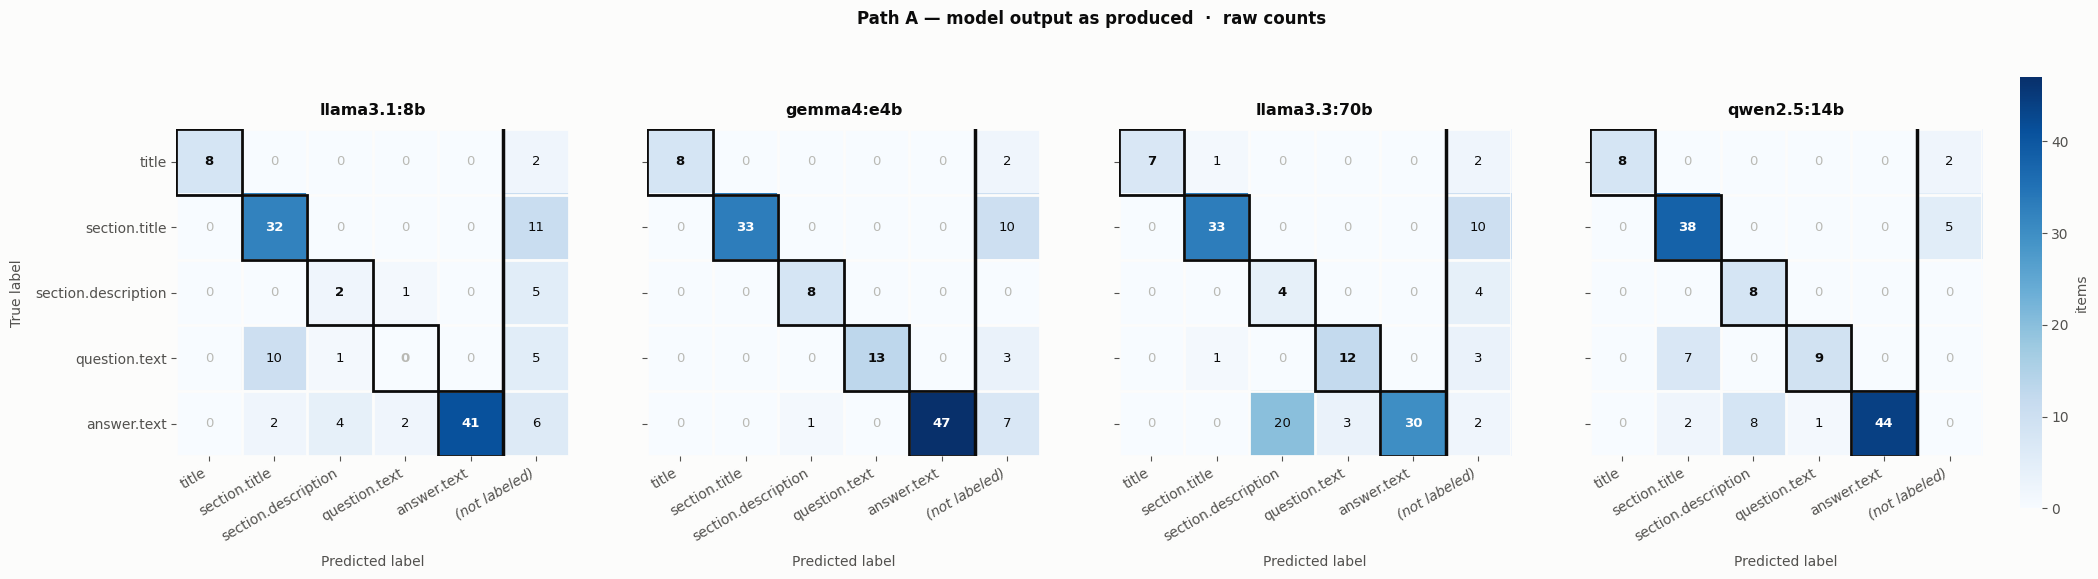

saved -> Report-doc\confusion_counts_pathB_pdfplumber_75pct.png


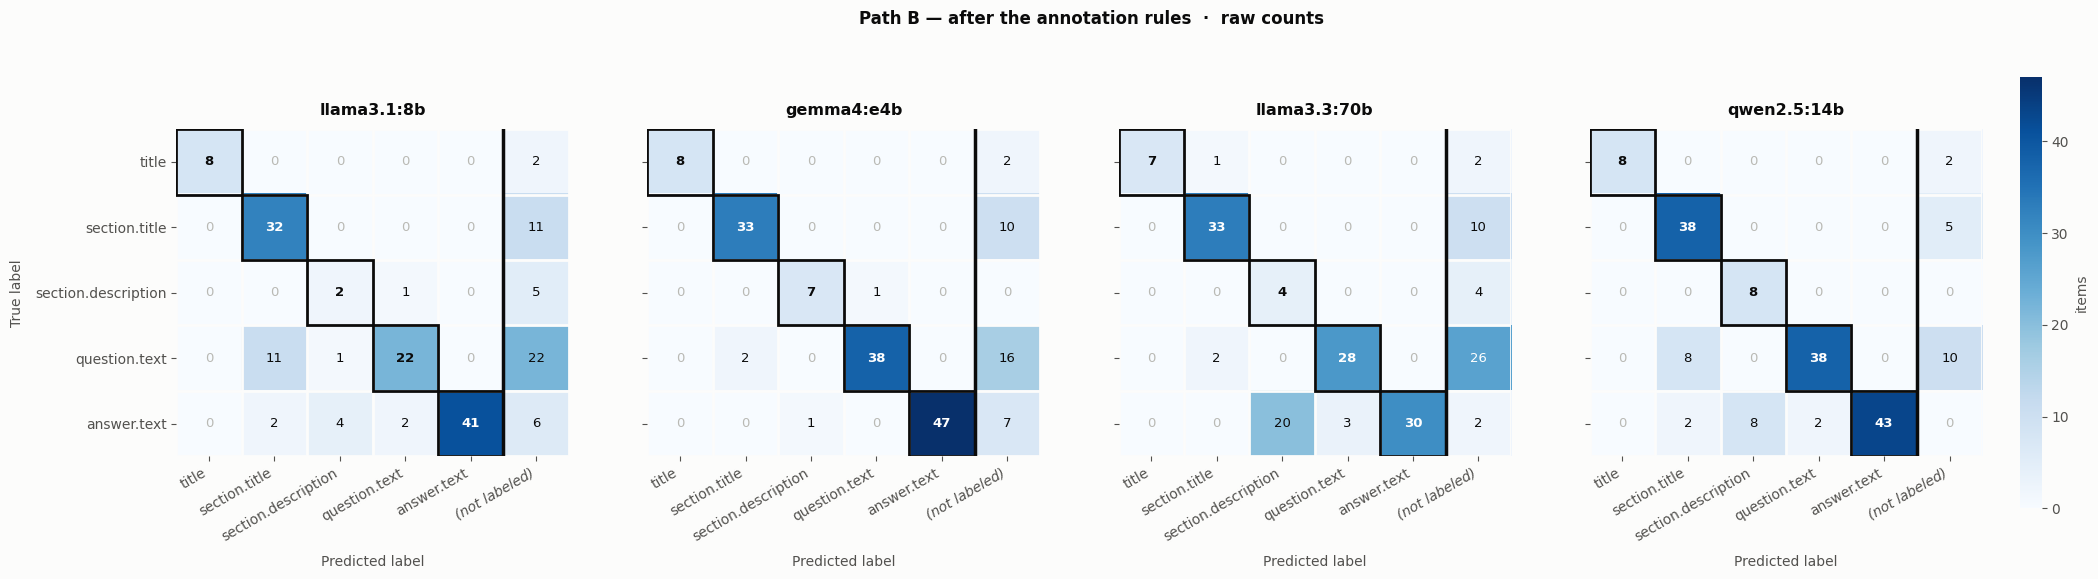

In [7]:
def build_counts(conf):
    """Same shape as build_pct, but raw counts instead of a share of the row."""
    counts = np.zeros((len(LABELS), len(KEYS)), dtype=int)
    for i, t in enumerate(LABELS):
        for j, key in enumerate(KEYS):
            counts[i, j] = conf.get(t, {}).get(key, 0)
    return counts


def draw_path_counts(path):
    """Counts version of draw_path — one figure, models side by side."""
    ncol = max(len(available), 1)
    fig, axes = plt.subplots(1, ncol, figsize=(6.1 * ncol, 5.6),
                             squeeze=False)
    # one shared scale for every panel, so the same shade always means the same
    # count — a row's own max would make a 7 in a small row look as dark as a 35
    # in a big one, which misrepresents the numbers rather than just simplifying them
    all_counts = [build_counts(CONF[m][path]) for m in available]
    vmax = max(cm.max() for cm in all_counts)
    for c, (m, cm) in enumerate(zip(available, all_counts)):
        ax = axes[0][c]
        im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax)
        for i in range(len(LABELS)):
            for j in range(len(KEYS)):
                v = int(cm[i, j])
                ax.text(j, i, str(v) if v else '0', ha='center', va='center',
                        fontsize=9.5, fontweight='bold' if i == j else 'normal',
                        color='#b9b9b4' if v == 0
                        else ('white' if v / vmax > 0.55 else INK))
        ax.set_xticks(range(len(COLS)))
        ax.set_yticks(range(len(LABELS)))
        ax.set_xticklabels(COLS, rotation=30, ha='right')
        ax.set_yticklabels(LABELS if c == 0 else [])
        ax.set_xlabel('Predicted label', labelpad=8)
        if c == 0:
            ax.set_ylabel('True label', labelpad=8)
        ax.set_title(m, pad=10)
        ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
        ax.grid(which='minor', color=SURFACE, linewidth=2)
        ax.tick_params(which='minor', length=0)
        for k in range(len(LABELS)):
            ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                       edgecolor=INK, linewidth=2.0, zorder=5))
        ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
        ax.get_xticklabels()[-1].set_style('italic')
        for spine in ax.spines.values():
            spine.set_visible(False)

    fig.suptitle(f'{PATH_NAMES[path]}  ·  raw counts',
                 fontweight='bold', y=1.00)
    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='items')
    cbar.outline.set_visible(False)
    suffix = '' if THRESHOLD is None else f'_{int(THRESHOLD * 100)}pct'
    out = Path(f'Report-doc/confusion_counts_path{path}_pdfplumber{suffix}.png')
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
    print(f'saved -> {out}')
    plt.show()


draw_path_counts('A')
draw_path_counts('B')


**One scale for the whole figure** — the darkest cell across all three models sets
the top of the colour bar, so a given shade means the same count everywhere: in
`answer.text` (55 items) and in `section.description` (8 items) alike, in every panel.
The percentage matrix above answers "how well is this class doing"; this one answers
"how many items is that", on the same footing throughout.


**Across a row** — find the same cell in each model and compare. The `question.text`
row is the most informative: the share sitting in the `section.title` column is the
lettered-sub-item confusion, and its size separates the models more clearly than any
headline score does.

**Down a column** — the same model before and after the annotation rules. The rules
only ever write to `question.text`, so every other row should be identical between
the two panels. Anything else moving would mean the rules had overreached.

*(Path B's `question.text` row is judged against the revised annotation, which has
more question items — so its percentages use a larger denominator than Path A's.)*


## 4. The missing items — what is in the `(not labeled)` column

The last column of every matrix is a percentage. This section opens it up: **which**
annotation items got nothing, not just how many.

They are found from the same matching that builds the matrix. `_match_structured()`
returns one record per annotation item; a record with `pred_label = None` is an item
no prediction claimed. Nothing new is computed here, so this listing and the matrix
can never disagree.


In [8]:
def missing_items(model, path):
    """Annotation items that no predicted item claimed, for one model and path."""
    tag = P.make_tag(model, EXTRACTOR)
    rows = []
    for n in SAMPLES:
        if path == 'A':
            gold = extract_gold(resolve_old_gt_path(n))
            dedup = True
        else:
            gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
            dedup = False
        records, _ = _match_structured(P.structured_path(tag, n), gold,
                                       dedup_question_title=dedup,
                                       threshold=THRESHOLD)
        for r in records:
            if r['pred_label'] is None:          # nothing claimed this item
                rows.append({'sample': n, 'label': r['gold_label'],
                             'annotation text': r['gold_text'][:70]})
    return pd.DataFrame(rows)


# how many, and what share of each class — the same numbers as the matrix column
summary = []
for m in available:
    for path in ('A', 'B'):
        miss, conf = missing_items(m, path), CONF[m][path]
        for lab in LABELS:
            total = sum(conf.get(lab, {}).values())
            n_missing = int((miss['label'] == lab).sum()) if len(miss) else 0
            if total:
                summary.append({'model': m, 'path': path, 'label': lab,
                                'not labeled': n_missing, 'of total': total,
                                '%': n_missing / total})

summary = pd.DataFrame(summary)
display(summary[summary['not labeled'] > 0]
        .pivot_table(index=['model', 'path'], columns='label', values='%')
        .style.format('{:.0%}', na_rep='—')
        .background_gradient(cmap='Reds', vmin=0, vmax=1))


### 4a. Verify: does every row now actually sum to 100%?

Checked directly against the raw confusion counts, not assumed.


In [9]:
print('row = (each predicted label) + (not labeled), as a share of the row total\n')
all_ok = True
for m in available:
    for path in ('A', 'B'):
        conf = CONF[m][path]
        for lab in LABELS:
            row = conf.get(lab, {})
            total = sum(row.values())
            if not total:
                continue
            labeled = sum(v for k, v in row.items() if k in LABELS)
            missed = row.get('__missed__', 0)
            pct = (labeled + missed) / total
            if abs(pct - 1.0) > 1e-9:
                all_ok = False
                print(f'  MISMATCH {m} Path {path} / {lab}: sums to {pct:.1%}, not 100%')

print('every row sums to exactly 100%' if all_ok else 'SEE MISMATCHES ABOVE')


row = (each predicted label) + (not labeled), as a share of the row total

every row sums to exactly 100%


### 4b. Which sample each missing item comes from

The `(not labeled)` share is not spread evenly across the 10 documents — most of it
comes from one or two. Pooling every model together, by sample:


In [10]:
pooled = pd.concat([missing_items(m, 'A').assign(model=m) for m in available],
                   ignore_index=True)

by_sample = (pooled.pivot_table(index='sample', columns='label', values='model',
                                aggfunc='count', fill_value=0))
by_sample['total'] = by_sample.sum(axis=1)
by_sample = by_sample.sort_values('total', ascending=False)
display(by_sample.style.background_gradient(cmap='Reds', subset=by_sample.columns[:-1]))

top2 = by_sample['total'].head(2).sum()
print(f"\nthe top 2 samples ({', '.join('sample ' + str(s) for s in by_sample.index[:2])}) "
      f"account for {top2} of {by_sample['total'].sum()} missing items "
      f"= {top2 / by_sample['total'].sum():.0%}, pooled across all {len(available)} models")


label,answer.text,question.text,section.description,section.title,title,total
sample,,,,,,
9,0,0,0,20,4,24
2,10,11,1,1,0,23
3,0,0,8,10,4,22
6,5,0,0,5,0,10



the top 2 samples (sample 9, sample 2) account for 47 of 79 missing items = 59%, pooled across all 4 models


**It is not spread across the corpus — it is two documents.** Samples 2 and 6 alone
hold the large majority of every model's `(not labeled)` items. Every model loses its
`section.title` items in sample 6 specifically (the underlined-heading problem, walked
through below); sample 2's bold run-in headings and long answers cause the rest.

The other eight documents contribute almost nothing to this column — so the
`(not labeled)` percentage in the matrix is not a diffuse property of the model, it is
concentrated in the two documents whose headings the extractor cannot separate from
their answers.


Every figure above is the `(not labeled)` cell of the matching matrix cell, so the
two agree by construction. Now the items themselves:


In [11]:
for m in available:
    miss = missing_items(m, 'A')
    print(f'{m} — Path A: {len(miss)} annotation items never produced')
    if len(miss):
        display(miss.sort_values(['label', 'sample']).style.hide(axis='index'))
    print()


llama3.1:8b — Path A: 29 annotation items never produced


sample,label,annotation text
2,answer.text,The proposed research in this proposal includes both computational and
2,answer.text,"Data are output from the various instruments in lab in formats, which"
2,answer.text,Research conducted within the Center will be published in appropriate
2,answer.text,Senior investigators typically archive relevant data using their own g
2,answer.text,"Generally, the volume of data generated by CBES researchers should not"
2,answer.text,Data that may support intellectual property claims will be published o
2,question.text,Roles & Responsibilities.
2,question.text,Content and Format. A statement of plans for data and metadata content
2,question.text,Data Sharing and Data Preservation. A description of the plans for dat
2,question.text,Data Repositories.



gemma4:e4b — Path A: 22 annotation items never produced


sample,label,annotation text
2,answer.text,Senior investigators typically archive relevant data using their own g
2,answer.text,"Generally, the volume of data generated by CBES researchers should not"
6,answer.text,"The bulk of the data generated in this project will be 1, 2, 3, and 4"
6,answer.text,The PI's research group will adopt the longstanding practice that all
6,answer.text,Interested parties will be able to request data and codes at the end o
6,answer.text,Simulation data will in essence grow to several terrabytes with an ass
6,answer.text,Local data will be archived on the group's mass storage system. As men
2,question.text,Roles & Responsibilities.
2,question.text,Data Repositories.
2,question.text,Data Volume.



llama3.3:70b — Path A: 21 annotation items never produced


sample,label,annotation text
2,answer.text,Senior investigators typically archive relevant data using their own g
2,answer.text,"Generally, the volume of data generated by CBES researchers should not"
2,question.text,Roles & Responsibilities.
2,question.text,Data Repositories.
2,question.text,Data Volume.
3,section.description,The Data Management Plan should clearly articulate how the PI and co-P
3,section.description,"The Data Management Plan should describe the types of data, samples, p"
3,section.description,The Data Management Plan should describe the period of time the data w
3,section.description,The Data Management Plan should describe the mechanisms and formats fo
3,section.title,Roles and responsibilities



qwen2.5:14b — Path A: 7 annotation items never produced


sample,label,annotation text
9,section.title,Products of Research
9,section.title,Data Format Standards
9,section.title,Access and sharing
9,section.title,"Policies and provisions for re-use, re-distribution, and production of"
9,section.title,"Archiving of Data, Samples, and Other Relevant Research Products"
3,title,CPS 2015
9,title,CAREER: HIGH-RESOLUTION NMR FOR PARAMAGNETIC SODIUM ELECTRODES


**How to read this.** An item here is not a labeling mistake — the model never put
out anything matching this text at all. Two things cause it:

1. **The text never survived extraction as its own item.** The underlined headings in
   sample 6 arrive fused to their answers, so the heading exists in no block of its
   own and can never be matched. This is the extractor's doing.
2. **The model merged it into a neighbour.** Stage 3 joins consecutive blocks carrying
   the same label, so a heading labeled the same as the answer beneath it disappears
   into that answer.

Both show up here identically, which is why the per-document fault test in the error
analysis is needed to tell them apart.


### Worked example — how one missing label is found, in sample 6

Sample 6 loses all five of its `section.title` items. Taking one of them and running
the matcher by hand shows exactly why.


In [12]:
n, model = 6, available[0]
thr = CONTAINMENT_THRESHOLD if THRESHOLD is None else THRESHOLD

gold = extract_gold(resolve_old_gt_path(n))
preds = extract_gold(P.structured_path(P.make_tag(model, EXTRACTOR), n))
print(f'{model}, sample {n}: {len(gold)} annotation items, {len(preds)} produced')

heading = next(t for t, l in gold if l == 'section.title' and 'Types of data' in t)
print(f'\nlooking for this annotation item:')
print(f'    "{heading}"   [section.title]')

# step 1 — score EVERY produced item against it
scored = sorted(((containment(tokenize(pt), tokenize(heading)), pt, pl)
                 for pt, pl in preds), key=lambda x: -x[0])
print('\nthe three closest produced items:')
for s, pt, pl in scored[:3]:
    print(f'    {s:5.0%}  [{pl:<19}] {pt[:52]}')
print(f'\n    best is {scored[0][0]:.0%}, the threshold is {thr:.0%}'
      ' -> nothing claims it -> (not labeled)')


llama3.1:8b, sample 6: 11 annotation items, 11 produced

looking for this annotation item:
    "Types of data"   [section.title]

the three closest produced items:
      75%  [section.title      ] 1. Types of data.
      33%  [title              ] Data Management Plan:
      20%  [section.title      ] 2. Data and metadata standards.

    best is 75%, the threshold is 75% -> nothing claims it -> (not labeled)


The heading's words are not missing from the document — so where did they go?


In [13]:
# every produced item whose words INCLUDE the whole heading
swallowed = [(pt, pl) for pt, pl in preds if tokenize(heading) <= tokenize(pt)]
print(f'produced items containing all of "{heading}": {len(swallowed)}')
for pt, pl in swallowed:
    print(f'    [{pl}] {pt[:88]}')

# step 2 — what does that item match instead?
fused = swallowed[0][0]
s, gt, gl = max(((containment(tokenize(fused), tokenize(g)), g, l)
                 for g, l in gold), key=lambda x: x[0])
print(f'\nthat item scores {s:.0%} against a different annotation item:')
print(f'    [{gl}] {gt[:88]}')
print(f'\n    so it is claimed by the {gl} item, and the heading is left with nothing.')


produced items containing all of "Types of data": 1
    [section.title] 1. Types of data.

that item scores 75% against a different annotation item:
    [section.title] Types of data

    so it is claimed by the section.title item, and the heading is left with nothing.


**That is the whole mechanism.** The heading `Types of data` is underlined rather than
bold, and an underline is a drawn line the reader cannot see — so the heading arrives
glued to the front of its answer, in one block.

That block is mostly answer words, so:

- scored against the **heading**, only a few of its words are inside it — far below the
  threshold, so it cannot claim the heading;
- scored against the **answer**, nearly all of its words are inside — so it claims that.

One block, two annotation items, one label. The answer is matched and the heading is
counted as not labeled. No label the model could have chosen would avoid this, which
is why sample 6 is scored as the extractor's failure rather than the model's.


## 5. The same two documents, but in Path B

Samples 2 and 6 drive most of Path A's `(not labeled)` count, and there it was
extraction — a block fused before any model ran, so all three models missed the same
items. **In Path B the missing items are not the same across models.** This section
shows why, with the same restrict-to-two-documents matrix used for Path A.


saved -> Report-doc\confusion_counts_pathA_samples2and6_75pct.png


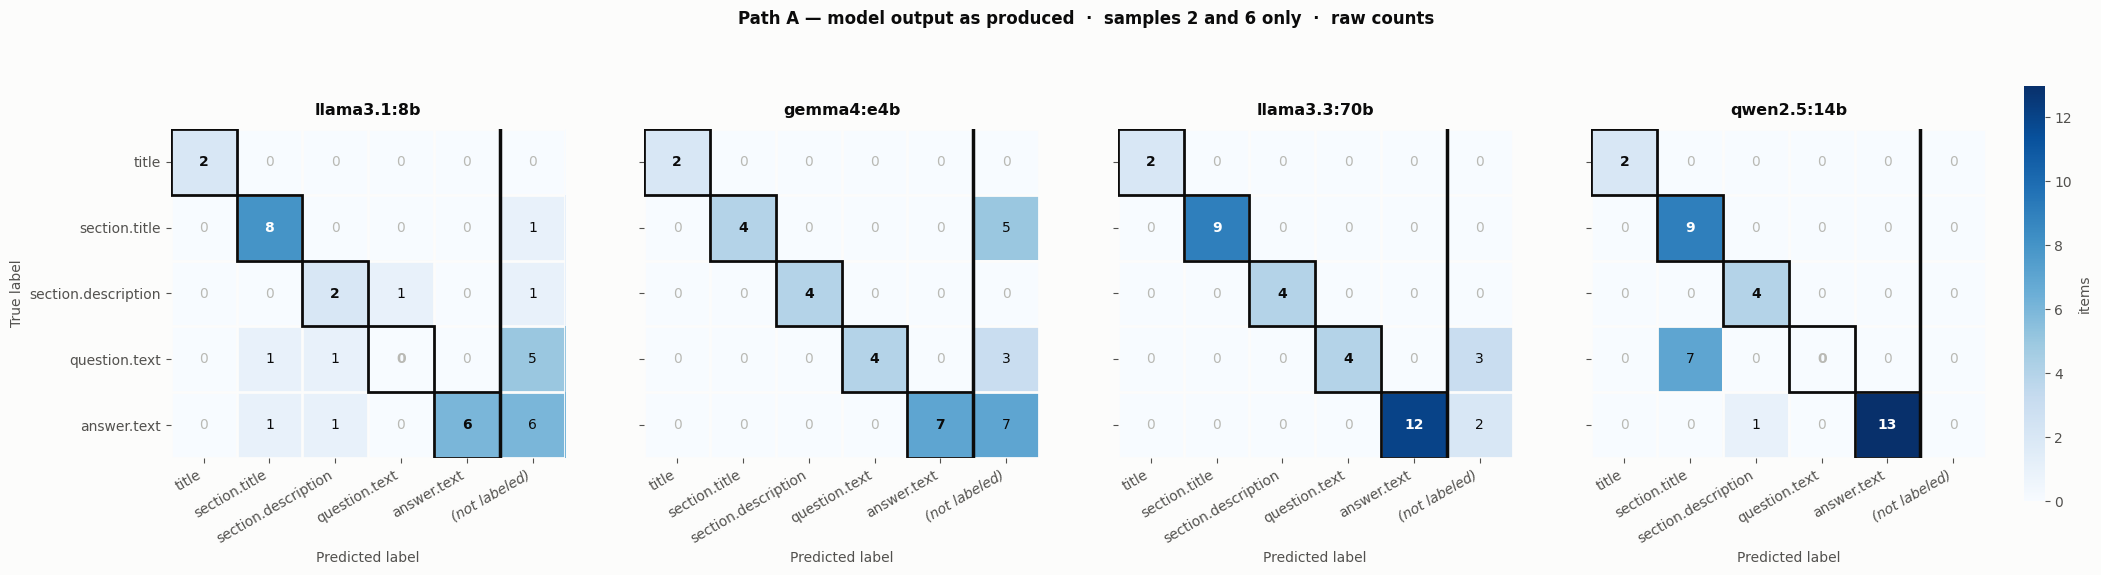

saved -> Report-doc\confusion_counts_pathB_samples2and6_75pct.png


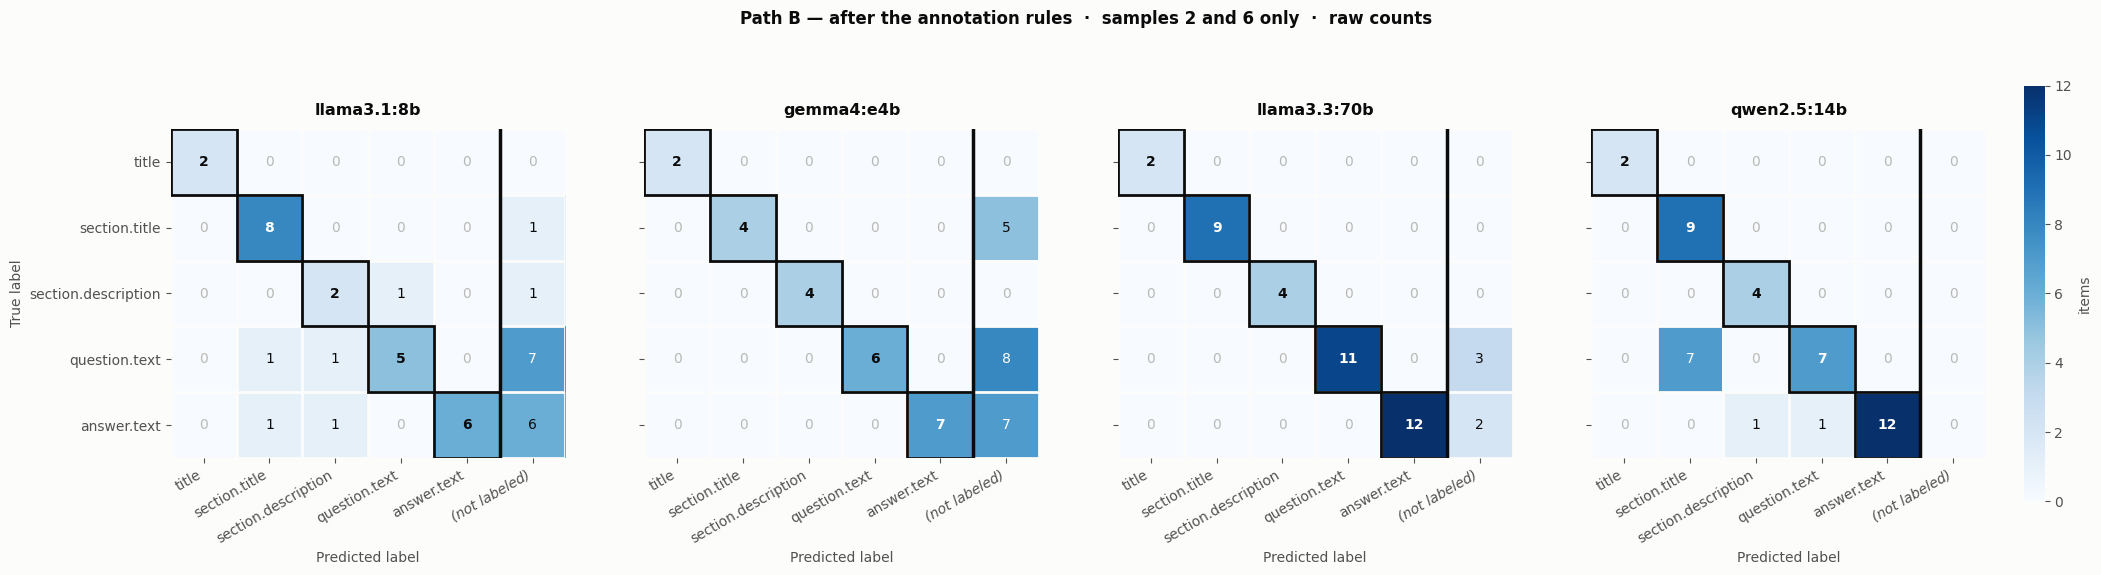

In [14]:
from collections import defaultdict


def counts_for(samples, path):
    """Raw-count matrix like build_counts, restricted to a handful of samples."""
    out = {}
    for m in available:
        tag = P.make_tag(m, EXTRACTOR)
        conf = defaultdict(lambda: defaultdict(int))
        for n in samples:
            if path == 'A':
                gold = extract_gold(resolve_old_gt_path(n))
                pred_path, dedup = P.structured_path(tag, n), True
            else:
                gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
                pred_path, dedup = P.final_path(tag, n), False
            records, no_gold = _match_structured(pred_path, gold, dedup_question_title=dedup,
                                                 threshold=THRESHOLD)
            add_confusion(conf, _confusion_from_match(records, no_gold))
        cm = np.zeros((len(LABELS), len(KEYS)), dtype=int)
        for i, t in enumerate(LABELS):
            for j, key in enumerate(KEYS):
                cm[i, j] = conf.get(t, {}).get(key, 0)
        out[m] = cm
    return out


def draw_restricted(samples, path, label):
    mats = counts_for(samples, path)
    vmax = max(m.max() for m in mats.values())
    fig, axes = plt.subplots(1, len(available), figsize=(6.1 * len(available), 5.4),
                             squeeze=False)
    for c, m in enumerate(available):
        ax, cm = axes[0][c], mats[m]
        im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=vmax)
        for i in range(len(LABELS)):
            for j in range(len(KEYS)):
                v = int(cm[i, j])
                ax.text(j, i, str(v) if v else '0', ha='center', va='center', fontsize=10,
                        fontweight='bold' if i == j else 'normal',
                        color='#b9b9b4' if v == 0 else ('white' if v / vmax > 0.55 else INK))
        ax.set_xticks(range(len(COLS))); ax.set_yticks(range(len(LABELS)))
        ax.set_xticklabels(COLS, rotation=30, ha='right')
        ax.set_yticklabels(LABELS if c == 0 else [])
        ax.set_xlabel('Predicted label')
        if c == 0:
            ax.set_ylabel('True label')
        ax.set_title(m, pad=10)
        ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
        ax.grid(which='minor', color=SURFACE, linewidth=2)
        ax.tick_params(which='minor', length=0)
        for k in range(len(LABELS)):
            ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                                       edgecolor=INK, linewidth=2.0, zorder=5))
        ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
        ax.get_xticklabels()[-1].set_style('italic')
        for s in ax.spines.values():
            s.set_visible(False)
    cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='items')
    cbar.outline.set_visible(False)
    fig.suptitle(f'{label}  ·  samples 2 and 6 only  ·  raw counts',
                 fontweight='bold', y=1.02)
    suffix = '' if THRESHOLD is None else f'_{int(THRESHOLD * 100)}pct'
    out = Path(f'Report-doc/confusion_counts_path{path}_samples2and6{suffix}.png')
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
    print(f'saved -> {out}')
    plt.show()


draw_restricted([2, 6], 'A', 'Path A — model output as produced')
draw_restricted([2, 6], 'B', 'Path B — after the annotation rules')


**Path A's `section.title` row is identical across models** — 4 correct, 5
`(not labeled)`, every time. That is the fused-block effect from section 4d, and it
cannot depend on the model because the block is fixed before labeling starts.

**Path B has no row that lines up so cleanly.** The counts move by model, which means
something *after* extraction is now deciding the outcome.


### Worked example — why Path B disagrees

The revised annotation adds a second gold item for some sections: the section title,
repeated as `question.text`. The annotation rules exist to fill that in automatically
— **but only when the model left the question text empty.** If the model already wrote
something there, the rule leaves it alone.

So the outcome depends on whether each model's own `question.text` field was empty at
stage 3, before the rules ever ran:


In [15]:
import json


def question_fill_state(model, sample, section_contains):
    """Did this model leave the question text empty for a given section?"""
    tag = P.make_tag(model, EXTRACTOR)
    data = json.loads(P.structured_path(tag, sample).read_text(encoding='utf-8'))
    template = data.get('narrative', data).get('template', {})
    for sec in template.get('section', []):
        if section_contains.lower() in (sec.get('title') or '').lower():
            qs = sec.get('question', [])
            return [bool((q.get('text') or '').strip()) for q in qs]
    return None


for target in ('Data used in publications', 'Confidentiality, security and rights'):
    print(f'section: "{target}"')
    for m in available:
        filled = question_fill_state(m, 2, target)
        state = 'wrote real text -> rule leaves it -> MISSES the added item' if filled and filled[0] \
            else 'left it blank -> rule copies the title in -> MATCHES the added item'
        print(f'    {m:<14} question.text filled: {filled}   {state}')
    print()


section: "Data used in publications"
    llama3.1:8b    question.text filled: [True]   wrote real text -> rule leaves it -> MISSES the added item
    gemma4:e4b     question.text filled: [False]   left it blank -> rule copies the title in -> MATCHES the added item
    llama3.3:70b   question.text filled: [False]   left it blank -> rule copies the title in -> MATCHES the added item
    qwen2.5:14b    question.text filled: [False]   left it blank -> rule copies the title in -> MATCHES the added item

section: "Confidentiality, security and rights"
    llama3.1:8b    question.text filled: [False]   left it blank -> rule copies the title in -> MATCHES the added item
    gemma4:e4b     question.text filled: [False]   left it blank -> rule copies the title in -> MATCHES the added item
    llama3.3:70b   question.text filled: [False]   left it blank -> rule copies the title in -> MATCHES the added item
    qwen2.5:14b    question.text filled: [False]   left it blank -> rule copies the title i

**A model that wrote a real answer here is penalised; a model that left the field
blank is rewarded.** That is backwards from what the metric is supposed to measure —
this is a scoring artifact of the rule interacting with each model's own output, not a
real difference in labeling ability. Which specific models land on which side of this
depends on their own current output (see the cell above for this run's actual split),
not something fixed to name here — it is why the `(not labeled)` counts in Path B
cannot be read the same way as Path A's: Path A's are caused by the extractor and apply
equally to every model; Path B's depend on an incidental detail of how each model
happened to fill one field.
